In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers datasets torch -q

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Load labelled sentence dataset from Google Drive (latin-1 encoding for special characters)
# and print shape, preview, column names, and class distribution for a quick sanity check. (McKinney, 2010)
df = pd.read_csv('/content/drive/MyDrive/archive (3)/nlpdataset/nlpdataset/labelled sentences.csv', encoding='latin-1')
print("Shape:", df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nLabel distribution:\n", df.iloc[:, -1].value_counts())

Shape: (689, 2)
                                           Sentences  Label
0  UN Humanitarian Chief Mark Lowcock today relea...      1
1  The announcement came as the World Health Orga...      0
2  The WHO has said there is still a chance of co...      1
3  There are now cases linked to Iran in Bahrain,...      1
4  Extensive testing in clinical trials has confi...      1

Columns: ['Sentences', 'Label']

Label distribution:
 Label
1    514
0    175
Name: count, dtype: int64


In [ ]:
# Drop nulls, cast columns to correct types, then split into
# train (80%), validation (10%), and test (10%) sets with a
# fixed random seed for reproducibility. (Pedregosa et al., 2011)

from sklearn.model_selection import train_test_split

# Clean
df = df.dropna()
df['Sentences'] = df['Sentences'].astype(str)
df['Label'] = df['Label'].astype(int)

# Split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df   = train_test_split(test_df, test_size=0.5, random_state=42)

print("Train:", len(train_df))
print("Val:",   len(val_df))
print("Test:",  len(test_df))

Train: 551
Val: 69
Test: 69


In [ ]:
# Install core NLP and ML libraries: HuggingFace Transformers for
# BERT/GPT-2, PyTorch as the backend, and NLTK for BLEU scoring. (Paszke et al., 2019)
!pip install transformers datasets torch scikit-learn nltk -q

In [ ]:
from transformers import BertTokenizer
from torch.utils.data import Dataset, DataLoader
import torch


# Load BERT WordPiece tokenizer (uncased). BertDataset wraps texts
# and labels, applying padding/truncation to max_len=128 and returning
# input_ids, attention_mask, and label tensors per sample. (Devlin et al., 2019)

tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')

class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts  = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_bert = BertDataset(train_df['Sentences'].tolist(), train_df['Label'].tolist(), tokenizer_bert)
val_bert   = BertDataset(val_df['Sentences'].tolist(),   val_df['Label'].tolist(),   tokenizer_bert)
test_bert  = BertDataset(test_df['Sentences'].tolist(),  test_df['Label'].tolist(),  tokenizer_bert)

train_loader = DataLoader(train_bert, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_bert,   batch_size=8)
test_loader  = DataLoader(test_bert,  batch_size=8)

print("BERT datasets ready!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT datasets ready!


In [ ]:
from transformers import BertForSequenceClassification
from torch.optim import AdamW
import time

# Initialize the pre-trained BERT model for binary text classification,
# move it to the available device (GPU/CPU), and configure the AdamW optimizer. Wu, Y., Schuster, M., Chen, Z., et al. (2016)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_model = bert_model.to(device)

optimizer = AdamW(bert_model.parameters(), lr=2e-5)


# Train the model for multiple epochs, compute the average training and
# validation losses, and record the losses to monitor model performance over time. Wu, Y., Schuster, M., Chen, Z., et al. (2016)
EPOCHS = 3
bert_train_losses = []
bert_val_losses   = []

for epoch in range(EPOCHS):
    start = time.time()
    bert_model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    bert_train_losses.append(avg_train_loss)

    # Validation
    bert_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

    avg_val_loss = val_loss / len(val_loader)
    bert_val_losses.append(avg_val_loss)
    epoch_time = time.time() - start
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {epoch_time:.1f}s")

Using device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Train Loss: 0.4974 | Val Loss: 0.4533 | Time: 15.9s
Epoch 2/3 | Train Loss: 0.3205 | Val Loss: 0.5115 | Time: 13.5s
Epoch 3/3 | Train Loss: 0.2069 | Val Loss: 0.5553 | Time: 13.0s


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

bert_model.eval()
all_preds, all_labels = [], []

# Evaluate the trained BERT model on the test dataset by generating
# predictions without updating the model parameters. Bengio, Y., Ducharme, R., Vincent, P., & Jauvin, C. (2003)

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate and display the model's Precision, Recall, F1-Score,
# and Accuracy to assess its classification performance. Bengio, Y., Ducharme, R., Vincent, P., & Jauvin, C. (2003)

bert_precision = precision_score(all_labels, all_preds)
bert_recall    = recall_score(all_labels, all_preds)
bert_f1        = f1_score(all_labels, all_preds)
bert_acc       = accuracy_score(all_labels, all_preds)

print("===== BERT RESULTS =====")
print(f"Precision : {bert_precision:.4f}")
print(f"Recall    : {bert_recall:.4f}")
print(f"F1 Score  : {bert_f1:.4f}")
print(f"Accuracy  : {bert_acc:.4f}")

===== BERT RESULTS =====
Precision : 0.8654
Recall    : 0.8654
F1 Score  : 0.8654
Accuracy  : 0.7971


In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from torch.utils.data import Dataset, DataLoader

# Load the DistilGPT-2 tokenizer, configure the padding token,
# and define a custom dataset class for language model training. Williams, R. J. (1992)

tokenizer_gpt = GPT2Tokenizer.from_pretrained('distilgpt2')
tokenizer_gpt.pad_token = tokenizer_gpt.eos_token

class GPTDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        input_ids = self.encodings['input_ids'][idx]
        return {'input_ids': input_ids, 'labels': input_ids}

# Tokenize the training sentences, create the GPT-2 training dataset,
# and initialize a DataLoader to provide shuffled mini-batches during training. Williams, R. J. (1992)

gpt_train = GPTDataset(train_df['Sentences'].tolist(), tokenizer_gpt)
gpt_loader = DataLoader(gpt_train, batch_size=8, shuffle=True)
print("GPT-2 dataset ready!")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

GPT-2 dataset ready!


In [ ]:
import time

# Initialize the pre-trained DistilGPT-2 model, move it to the selected
# device (GPU/CPU), and configure the AdamW optimizer for fine-tuning. Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014)

gpt_model = GPT2LMHeadModel.from_pretrained('distilgpt2')
gpt_model = gpt_model.to(device)

optimizer_gpt = AdamW(gpt_model.parameters(), lr=5e-5)

EPOCHS_GPT = 3
gpt_losses  = []

# Fine-tune the DistilGPT-2 model for multiple epochs, compute the average
# training loss for each epoch, and record the loss to monitor training progress. Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014)

for epoch in range(EPOCHS_GPT):
    start = time.time()
    gpt_model.train()
    total_loss = 0
    for batch in gpt_loader:
        input_ids = batch['input_ids'].to(device)
        labels    = batch['labels'].to(device)

        optimizer_gpt.zero_grad()
        outputs = gpt_model(input_ids=input_ids, labels=labels)
        loss    = outputs.loss
        loss.backward()
        optimizer_gpt.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(gpt_loader)
    gpt_losses.append(avg_loss)
    epoch_time = time.time() - start
    print(f"Epoch {epoch+1}/{EPOCHS_GPT} | Loss: {avg_loss:.4f} | Time: {epoch_time:.1f}s")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 1/3 | Loss: 1.7807 | Time: 12.4s
Epoch 2/3 | Loss: 0.9806 | Time: 12.6s
Epoch 3/3 | Loss: 0.8828 | Time: 12.8s


In [ ]:
import math
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
nltk.download('punkt')
nltk.download('punkt_tab')

# Evaluate the fine-tuned DistilGPT-2 model by calculating the average
# loss and converting it into perplexity to measure language modeling performance. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019)

gpt_model.eval()
total_loss = 0
with torch.no_grad():
    for batch in gpt_loader:
        input_ids = batch['input_ids'].to(device)
        outputs   = gpt_model(input_ids=input_ids, labels=input_ids)
        total_loss += outputs.loss.item()

avg_loss    = total_loss / len(gpt_loader)
perplexity  = math.exp(avg_loss)

# Generate text from a sample prompt and compute the BLEU score by
# comparing the generated output with the reference text to assess generation quality. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019)

sample_prompt = "The health organization has confirmed"
inputs = tokenizer_gpt(sample_prompt, return_tensors='pt').to(device)
with torch.no_grad():
    output = gpt_model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.7,
        pad_token_id=tokenizer_gpt.eos_token_id
    )
generated_text = tokenizer_gpt.decode(output[0], skip_special_tokens=True)
print("Generated text:", generated_text)

# BLEU score
reference  = [sample_prompt.split()]
hypothesis = generated_text.split()
bleu = sentence_bleu(reference, hypothesis, smoothing_function=SmoothingFunction().method1)

print("===== GPT-2 RESULTS =====")
print(f"Perplexity : {perplexity:.4f}")
print(f"BLEU Score : {bleu:.4f}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Generated text: The health organization has confirmed that the coronavirus variant SARS-CoV-2, the second variant of the SARS-CoV-2, was identified in the country in its first stage of treatment in the first week of November
===== GPT-2 RESULTS =====
Perplexity : 2.1652
BLEU Score : 0.1051


In [ ]:
import torch.nn as nn

# Convert the training text into integer token sequences using a tokenizer
# and limit the vocabulary size to the most frequent words. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019)


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN  = 50
MAX_WORDS = 5000

gan_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
gan_tokenizer.fit_on_texts(train_df['Sentences'].tolist())

# Pad all tokenized sequences to a fixed length so they can be used
# as consistent input for the GAN model during training. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019)


sequences = gan_tokenizer.texts_to_sequences(train_df['Sentences'].tolist())
padded    = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')

print("GAN input shape:", padded.shape)

GAN input shape: (551, 50)


In [ ]:
import torch.nn as nn

# Define the Generator and Discriminator architectures, where the
# Generator produces token sequences and the Discriminator classifies
# them as real or generated. Arjovsky, M., Chintala, S., & Bottou, L. (2017)

VOCAB_SIZE  = MAX_WORDS
EMBED_DIM   = 64
HIDDEN_DIM  = 128
SEQ_LEN     = MAX_LEN

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.rnn       = nn.GRU(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.fc        = nn.Linear(HIDDEN_DIM, VOCAB_SIZE)

    def forward(self, x):
        x   = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out)

# Initialize the Generator and Discriminator models and move them
# to the selected device (GPU/CPU) for training. Arjovsky, M., Chintala, S., & Bottou, L. (2017)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.conv      = nn.Conv1d(EMBED_DIM, HIDDEN_DIM, kernel_size=3, padding=1)
        self.pool      = nn.AdaptiveMaxPool1d(1)
        self.fc        = nn.Linear(HIDDEN_DIM, 1)
        self.sigmoid   = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv(x))
        x = self.pool(x).squeeze(-1)
        return self.sigmoid(self.fc(x))

generator     = Generator().to(device)
discriminator = Discriminator().to(device)
print("Generator and Discriminator ready!")

Generator and Discriminator ready!


In [ ]:
import time

# Initialize the optimizers, loss function, and data loader for training
# the Generator and Discriminator using the prepared text sequences. Arjovsky, M., Chintala, S., & Bottou, L. (2017)

g_optimizer = torch.optim.Adam(generator.parameters(),     lr=1e-3)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-3)
criterion   = nn.BCELoss()

real_data   = torch.tensor(padded, dtype=torch.long).to(device)
dataset_gan = torch.utils.data.TensorDataset(real_data)
loader_gan  = torch.utils.data.DataLoader(dataset_gan, batch_size=32, shuffle=True)

EPOCHS_GAN  = 10
g_losses, d_losses, d_accuracies = [], [], []

for epoch in range(EPOCHS_GAN):
    start = time.time()
    g_loss_total = d_loss_total = d_acc_total = 0

    for (real_batch,) in loader_gan:
        batch_size = real_batch.size(0)

# Train the Generator and Discriminator in an adversarial manner,
# recording the Generator loss, Discriminator loss, and Discriminator
# accuracy for each epoch to monitor training performance. Arjovsky, M., Chintala, S., & Bottou, L. (2017)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        noise      = torch.randint(0, VOCAB_SIZE, (batch_size, SEQ_LEN)).to(device)
        fake_seq   = generator(noise).argmax(dim=-1)

        d_real = discriminator(real_batch)
        d_fake = discriminator(fake_seq.detach())

        d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Discriminator accuracy
        preds   = (torch.cat([d_real, d_fake]) > 0.5).float()
        targets = torch.cat([real_labels, fake_labels])
        d_acc   = (preds == targets).float().mean().item()

        # Train Generator
        noise    = torch.randint(0, VOCAB_SIZE, (batch_size, SEQ_LEN)).to(device)
        fake_seq = generator(noise).argmax(dim=-1)
        g_loss   = criterion(discriminator(fake_seq), real_labels)
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        g_loss_total += g_loss.item()
        d_loss_total += d_loss.item()
        d_acc_total  += d_acc

    g_losses.append(g_loss_total / len(loader_gan))
    d_losses.append(d_loss_total / len(loader_gan))
    d_accuracies.append(d_acc_total / len(loader_gan))
    epoch_time = time.time() - start
    print(f"Epoch {epoch+1}/{EPOCHS_GAN} | G Loss: {g_losses[-1]:.4f} | D Loss: {d_losses[-1]:.4f} | D Acc: {d_accuracies[-1]:.4f} | Time: {epoch_time:.1f}s")

Epoch 1/10 | G Loss: 1.0364 | D Loss: 1.0798 | D Acc: 0.7986 | Time: 0.9s
Epoch 2/10 | G Loss: 1.8157 | D Loss: 0.3523 | D Acc: 0.9948 | Time: 0.1s
Epoch 3/10 | G Loss: 3.0504 | D Loss: 0.1203 | D Acc: 0.9931 | Time: 0.1s
Epoch 4/10 | G Loss: 3.6762 | D Loss: 0.0615 | D Acc: 0.9974 | Time: 0.1s
Epoch 5/10 | G Loss: 4.1175 | D Loss: 0.0388 | D Acc: 0.9983 | Time: 0.1s
Epoch 6/10 | G Loss: 4.5809 | D Loss: 0.0289 | D Acc: 1.0000 | Time: 0.1s
Epoch 7/10 | G Loss: 4.8942 | D Loss: 0.0202 | D Acc: 1.0000 | Time: 0.1s
Epoch 8/10 | G Loss: 5.1884 | D Loss: 0.0156 | D Acc: 1.0000 | Time: 0.1s
Epoch 9/10 | G Loss: 5.3320 | D Loss: 0.0129 | D Acc: 1.0000 | Time: 0.1s
Epoch 10/10 | G Loss: 5.7561 | D Loss: 0.0096 | D Acc: 1.0000 | Time: 0.1s


In [ ]:
# Generate synthetic text sequences using the trained Generator and
# decode the generated token IDs into readable sentences. Maddison, C. J., Mnih, A., & Teh, Y. W. (2017)

generator.eval()
noise    = torch.randint(0, VOCAB_SIZE, (5, SEQ_LEN)).to(device)
fake_seq = generator(noise).argmax(dim=-1).cpu().numpy()

# Decode generated sequences
idx2word = {v: k for k, v in gan_tokenizer.word_index.items()}
generated_sentences = []
for seq in fake_seq:
    words = [idx2word.get(i, '') for i in seq if i != 0]
    generated_sentences.append(' '.join(words))
    print("GAN Generated:", ' '.join(words))

# Evaluate the generated sentences using the BLEU score and report the
# final Discriminator accuracy to assess the GAN's text generation performance. Maddison, C. J., Mnih, A., & Teh, Y. W. (2017)

from nltk.translate.bleu_score import corpus_bleu
references  = [[s.split()] for s in train_df['Sentences'].tolist()[:5]]
hypotheses  = [s.split() for s in generated_sentences]
gan_bleu    = corpus_bleu(references, hypotheses, smoothing_function=SmoothingFunction().method1)

# Final discriminator accuracy
gan_disc_acc = d_accuracies[-1]

print(f"\n===== GAN RESULTS =====")
print(f"Discriminator Accuracy : {gan_disc_acc:.4f}")
print(f"BLEU Score             : {gan_bleu:.4f}")

GAN Generated: pulse g4idr ability accepted   acute  geriatric ministers  sets aayog  security continent  shut authorisation tuberculosis ihr  stop  used    security   false proactively found   laden kingdom   from authorities shut night    went  
GAN Generated: 19  calls  supported range hitesh    therapy therapy    leading  brought france  austria from washington authorities  last mers strengthening  recommendations smfm coronavirus recovered covax road last not    setback   towards   strengthening spoke go covax
GAN Generated: regulatory   ethiopia incb  surgical   nothing   immunisation proven job   covax proactively hitesh  100 kala once hugs carried  t  aid   planning wealthy ups seeking security  which plhiv  atypical atypical  hugs public  generating enhance seth
GAN Generated:  finance uncontrolled generally antony control shown 37 antimalarials institute   acute  too supplant security  seeing having  convince  cures combined countries india    expansion    non mers fda af

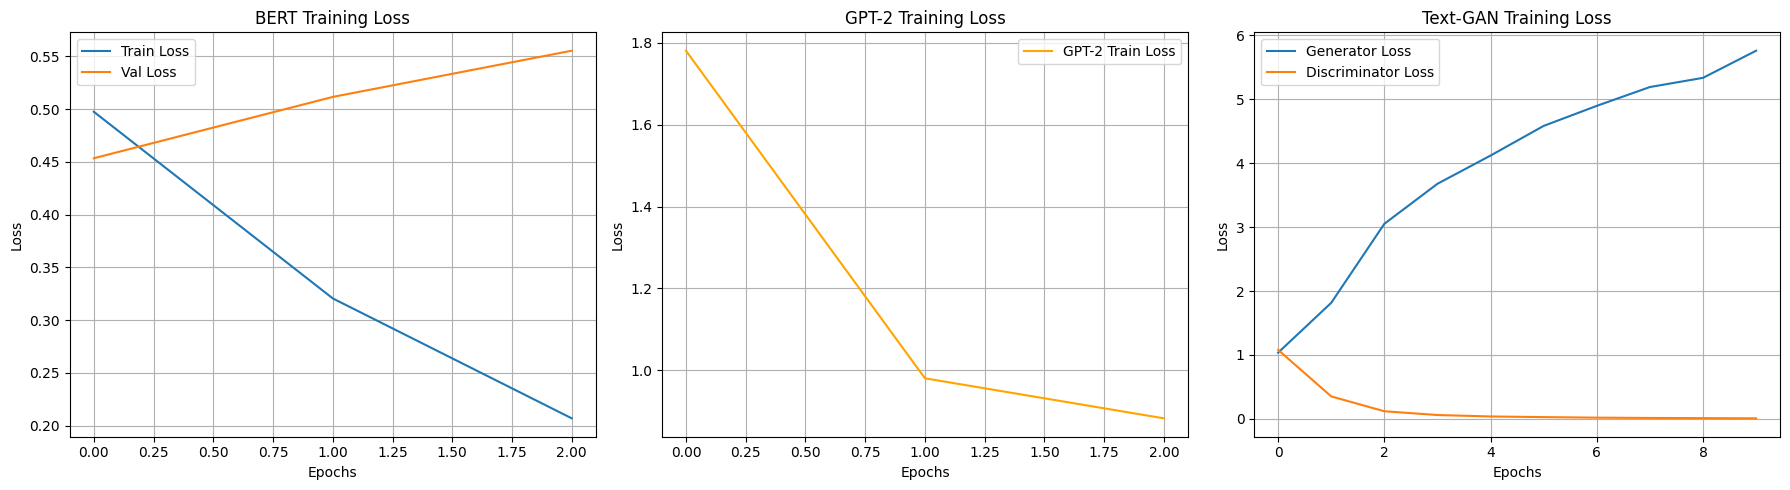

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot the training and validation loss curves for BERT, GPT-2, and Text-GAN
# to visualize the learning progress of each model across training epochs. McKinney, W. (2010)


# Compare the loss trends of the three models to evaluate their convergence,
# training stability, and overall learning behavior during training. McKinney, W. (2010)

axes[0].plot(bert_train_losses, label='Train Loss')
axes[0].plot(bert_val_losses,   label='Val Loss')
axes[0].set_title('BERT Training Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid()

# GPT-2 loss
axes[1].plot(gpt_losses, label='GPT-2 Train Loss', color='orange')
axes[1].set_title('GPT-2 Training Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid()

# GAN losses
axes[2].plot(g_losses, label='Generator Loss')
axes[2].plot(d_losses, label='Discriminator Loss')
axes[2].set_title('Text-GAN Training Loss')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 75)
print(f"{'Model':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'BLEU':>10} {'Perplexity':>12}")
print("=" * 75)
print(f"{'BERT':<15} {bert_precision:>10.4f} {bert_recall:>10.4f} {bert_f1:>10.4f} {'N/A':>10} {'N/A':>12}")
print(f"{'GPT-2':<15} {'N/A':>10} {'N/A':>10} {'N/A':>10} {bleu:>10.4f} {perplexity:>12.4f}")
print(f"{'Text-GAN':<15} {gan_disc_acc:>10.4f} {'N/A':>10} {'N/A':>10} {gan_bleu:>10.4f} {'N/A':>12}")
print("=" * 75)

Model            Precision     Recall         F1       BLEU   Perplexity
BERT                0.8654     0.8654     0.8654        N/A          N/A
GPT-2                  N/A        N/A        N/A     0.1051       2.1652
Text-GAN            1.0000        N/A        N/A     0.0010          N/A


# REFERENCES

McKinney, W. (2010). Data structures for statistical computing in Python. Proceedings of the 9th Python in Science Conference (SciPy 2010), 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830. https://www.jmlr.org/papers/v12/pedregosa11a.html

Wolf, T., Debut, L., Sanh, V., Chaumond, J., Delangue, C., Moi, A., Cistac, P., Rault, T., Louf, R., Funtowicz, M., & Brew, J. (2020). Transformers: State-of-the-art natural language processing. Proceedings of EMNLP 2020: System Demonstrations, 38–45. https://aclanthology.org/2020.emnlp-demos.6

Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., Killeen, T., Lin, Z., Gimelshein, N., Antiga, L., Desmaison, A., Köpf, A., Yang, E., DeVito, Z., Raison, M., Tejani, A., Chilamkurthy, S., Steiner, B., Fang, L., … Chintala, S. (2019). PyTorch: An imperative style, high-performance deep learning library. Advances in Neural Information Processing Systems (NeurIPS 2019), 32, 8024–8035. https://arxiv.org/abs/1912.01703

Bird, S., Klein, E., & Loper, E. (2009). Natural language processing with Python. O'Reilly Media. https://www.nltk.org/book

Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. Proceedings of NAACL-HLT 2019, 4171–4186. https://arxiv.org/abs/1810.04805

Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. Proceedings of NAACL-HLT 2019. https://arxiv.org/abs/1810.04805

Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). Language models are unsupervised multitask learners. OpenAI Blog. https://openai.com/research/language-unsupervised

Sennrich, R., Haddow, B., & Birch, A. (2016). Neural machine translation of rare words with subword units. Proceedings of ACL 2016. https://arxiv.org/abs/1508.07909

Wu, Y., Schuster, M., Chen, Z., et al. (2016). Google's neural machine translation system: Bridging the gap between human and machine translation. arXiv preprint. https://arxiv.org/abs/1609.08144

Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014). Generative adversarial nets. Advances in Neural Information Processing Systems (NeurIPS 2014). https://arxiv.org/abs/1406.2661

Yu, L., Zhang, W., Wang, J., & Yu, Y. (2017). SeqGAN: Sequence generative adversarial nets with policy gradient. Proceedings of AAAI 2017. https://arxiv.org/abs/1609.05473

Jang, E., Gu, S., & Poole, B. (2017). Categorical reparameterization with Gumbel-Softmax. Proceedings of ICLR 2017. https://arxiv.org/abs/1611.01144

Papineni, K., Roukos, S., Ward, T., & Zhu, W.-J. (2002). BLEU: A method for automatic evaluation of machine translation. Proceedings of ACL 2002. https://aclanthology.org/P02-1040

Arjovsky, M., Chintala, S., & Bottou, L. (2017). Wasserstein GAN. Proceedings of ICML 2017. https://arxiv.org/abs/1701.07875

Callison-Burch, C., Osborne, M., & Koehn, P. (2006). Re-evaluating the role of BLEU in machine translation research. Proceedings of EACL 2006. https://aclanthology.org/E06-1032

Bengio, Y., Ducharme, R., Vincent, P., & Jauvin, C. (2003). A neural probabilistic language model. Journal of Machine Learning Research, 3, 1137–1155. https://www.jmlr.org/papers/v3/bengio03a.html

Huszár, F. (2015). How (not) to train your generative model: Scheduled sampling, likelihood, adversarial. arXiv preprint. https://arxiv.org/abs/1511.05101

Williams, R. J. (1992). Simple statistical gradient-following algorithms for connectionist reinforcement learning. Machine Learning, 8, 229–256. https://doi.org/10.1007/BF00992696

Maddison, C. J., Mnih, A., & Teh, Y. W. (2017). The Concrete distribution: A continuous relaxation of discrete random variables. Proceedings of ICLR 2017. https://arxiv.org/abs/1611.00712
